In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from feature.selector import Selective, SelectionMethod
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
import shap
from lime.lime_tabular import LimeTabularExplainer
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

In [4]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("TARA_mhws_3.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_count'] = df_numeric['mhw_count'].astype(str)

df_numeric.loc[df_numeric['mhw_count'].isin(['2', '3']), 'mhw_count'] = '2+'


print(df_numeric['mhw_count'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

shuffled_df_numeric = shuffled_df_numeric.rename({'sea surface temp': 'SST', 'sea surface quantum fluorescence': 'SSQF',
                                                  'total suspended matter': 'TSM', 'particulate inorganic carbon': 'PIC'}, axis = 1)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y = shuffled_df_numeric['mhw_count']
X.shape, y.shape

mhw_count
0     3245
1      663
2+     158
Name: count, dtype: int64


((4066, 80), (4066,))

cross validation scores: [0.97174447 0.97416974 0.9704797  0.95694957 0.96432964]
0.9675 accuracy with a standard deviation of 0.0062
Accuracy: 96.19%
[[639  10   1]
 [ 18 115   0]
 [  2   0  29]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       650
           1       0.92      0.86      0.89       133
          2+       0.97      0.94      0.95        31

    accuracy                           0.96       814
   macro avg       0.95      0.93      0.94       814
weighted avg       0.96      0.96      0.96       814



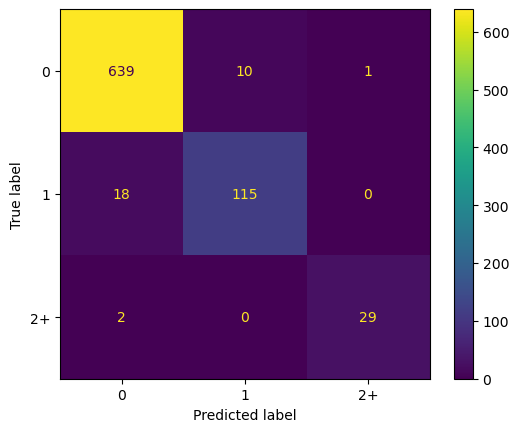

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.2, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(class_weight = 'balanced', random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp_3 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

In [5]:
param_grid = [
     {'min_samples_split': [2, 10, 50, 100],
     'min_samples_leaf': [1, 5, 10, 50],
     'max_features': [None, 'log2', 'sqrt'],
    'class_weight': ['balanced', 'balanced_subsample'],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20]
}]

grid = GridSearchCV(forest, param_grid, cv = 5, scoring = 'accuracy', verbose = 2)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits
[CV] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2; total time=   5.3s
[CV] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2; total time=   5.4s
[CV] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2; total time=   5.1s
[CV] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2; total time=   5.3s
[CV] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2; total time=   5.2s
[CV] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=10; total time=   5.3s
[CV] END class_weight=balanced, criterion=gini, max_depth=None, max_features=

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,5.369856,0.090304,0.011794,0.006121,balanced,gini,None,None,1,2,"{'class_weight': 'balanced', 'criterion': 'gin...",0.967742,0.961598,0.960000,0.958462,0.984615,0.966483,0.009598,58
1,5.403628,0.098505,0.013745,0.007557,balanced,gini,None,None,1,10,"{'class_weight': 'balanced', 'criterion': 'gin...",0.967742,0.966206,0.964615,0.958462,0.981538,0.967713,0.007597,41
2,5.055701,0.172989,0.007802,0.006651,balanced,gini,None,None,1,50,"{'class_weight': 'balanced', 'criterion': 'gin...",0.946237,0.943164,0.952308,0.943077,0.961538,0.949265,0.006994,151
3,4.487594,0.206161,0.012064,0.003416,balanced,gini,None,None,1,100,"{'class_weight': 'balanced', 'criterion': 'gin...",0.847926,0.855607,0.904615,0.907692,0.924615,0.888091,0.030528,575
4,5.015606,0.085862,0.011326,0.006940,balanced,gini,None,None,5,2,"{'class_weight': 'balanced', 'criterion': 'gin...",0.952381,0.966206,0.961538,0.953846,0.976923,0.962179,0.008938,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,0.947401,0.108482,0.010889,0.008990,balanced_subsample,entropy,20,sqrt,10,100,"{'class_weight': 'balanced_subsample', 'criter...",0.912442,0.921659,0.923077,0.930769,0.918462,0.921282,0.005991,422
764,0.885936,0.143337,0.016114,0.003061,balanced_subsample,entropy,20,sqrt,50,2,"{'class_weight': 'balanced_subsample', 'criter...",0.894009,0.897081,0.920000,0.896923,0.916923,0.904987,0.011099,537
765,1.119683,0.131574,0.011829,0.003827,balanced_subsample,entropy,20,sqrt,50,10,"{'class_weight': 'balanced_subsample', 'criter...",0.894009,0.897081,0.920000,0.896923,0.916923,0.904987,0.011099,537
766,1.049563,0.209891,0.015702,0.005577,balanced_subsample,entropy,20,sqrt,50,50,"{'class_weight': 'balanced_subsample', 'criter...",0.894009,0.897081,0.920000,0.896923,0.916923,0.904987,0.011099,537


cross validation scores: [0.97542998 0.97785978 0.97293973 0.96186962 0.96432964]
0.9705 accuracy with a standard deviation of 0.0063
Accuracy: 96.93%
[[634  14   2]
 [  8 125   0]
 [  1   0  30]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       650
           1       0.90      0.94      0.92       133
          2+       0.94      0.97      0.95        31

    accuracy                           0.97       814
   macro avg       0.94      0.96      0.95       814
weighted avg       0.97      0.97      0.97       814



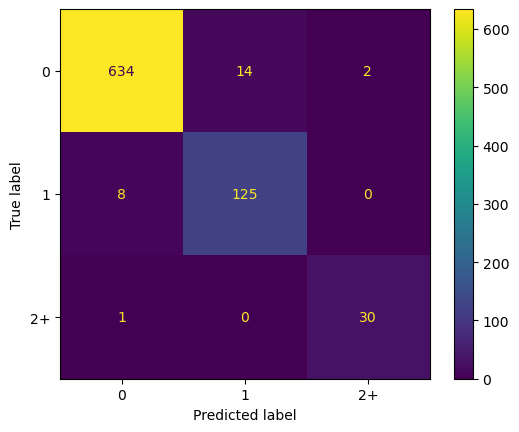

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.2, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(class_weight = 'balanced', criterion = 'entropy', max_depth = None, max_features = None, min_samples_split = 10,
                                random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp_3 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

In [8]:
param_grid = [
     {'min_samples_split': [5, 10, 15],
     'max_features': [None],
    'class_weight': ['balanced', None],
    'criterion': ['entropy'],
    'max_depth': [None]
}]

grid = GridSearchCV(forest, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
the best score was 0.9713054951298095
the best parameters were {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_split': 5}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_criterion,param_max_depth,param_max_features,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,7.410626,0.348737,0.013042,0.004066,balanced,entropy,None,None,5,"{'class_weight': 'balanced', 'criterion': 'ent...",0.967213,0.974044,0.971311,0.964481,0.969904,0.969391,0.003300,4
1,7.730706,0.181805,0.013114,0.004482,balanced,entropy,None,None,10,"{'class_weight': 'balanced', 'criterion': 'ent...",0.965847,0.968579,0.969945,0.965847,0.974008,0.968845,0.003030,5
2,7.725494,0.267932,0.012485,0.006658,balanced,entropy,None,None,15,"{'class_weight': 'balanced', 'criterion': 'ent...",0.960383,0.964481,0.965847,0.965847,0.968536,0.965019,0.002666,6
3,8.036750,0.356197,0.008498,0.007146,None,entropy,None,None,5,"{'class_weight': None, 'criterion': 'entropy',...",0.961749,0.980874,0.972678,0.963115,0.978112,0.971305,0.007723,1
4,7.906976,0.302919,0.017528,0.003412,None,entropy,None,None,10,"{'class_weight': None, 'criterion': 'entropy',...",0.956284,0.980874,0.975410,0.964481,0.978112,0.971032,0.009237,2
5,7.857148,0.386068,0.011557,0.006215,None,entropy,None,None,15,"{'class_weight': None, 'criterion': 'entropy',...",0.961749,0.974044,0.971311,0.965847,0.975376,0.969665,0.005133,3


In [9]:
param_grid = [
     {'min_samples_split': [5, 6, 7, 8, 9],
     'max_features': [None],
    'class_weight': [None],
    'criterion': ['entropy'],
    'max_depth': [None]
}]

grid = GridSearchCV(forest, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
the best score was 0.9718523169847428
the best parameters were {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_split': 7}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_criterion,param_max_depth,param_max_features,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,7.645953,0.207399,0.018298,0.003083,None,entropy,None,None,5,"{'class_weight': None, 'criterion': 'entropy',...",0.961749,0.980874,0.972678,0.963115,0.978112,0.971305,0.007723,3
1,7.836768,0.382890,0.015655,0.000523,None,entropy,None,None,6,"{'class_weight': None, 'criterion': 'entropy',...",0.960383,0.980874,0.976776,0.964481,0.976744,0.971852,0.007943,2
2,7.775879,0.229986,0.010769,0.006148,None,entropy,None,None,7,"{'class_weight': None, 'criterion': 'entropy',...",0.959016,0.979508,0.976776,0.964481,0.979480,0.971852,0.008487,1
3,7.820485,0.231307,0.009886,0.005989,None,entropy,None,None,8,"{'class_weight': None, 'criterion': 'entropy',...",0.959016,0.979508,0.976776,0.964481,0.975376,0.971032,0.007887,5
4,7.780286,0.214875,0.015929,0.000155,None,entropy,None,None,9,"{'class_weight': None, 'criterion': 'entropy',...",0.956284,0.980874,0.972678,0.964481,0.980848,0.971033,0.009554,4


cross validation scores: [0.97665848 0.98277983 0.9704797  0.96555966 0.96432964]
0.9720 accuracy with a standard deviation of 0.0069
Accuracy: 97.05%
[[640   9   1]
 [ 13 120   0]
 [  1   0  30]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       650
           1       0.93      0.90      0.92       133
          2+       0.97      0.97      0.97        31

    accuracy                           0.97       814
   macro avg       0.96      0.95      0.96       814
weighted avg       0.97      0.97      0.97       814



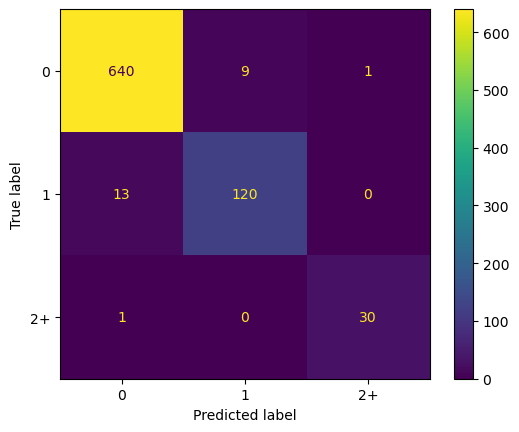

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.2, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(class_weight = None, criterion = 'entropy', max_depth = None, max_features = None, min_samples_split = 7,
                                random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp_3 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

cross validation scores: [0.97665848 0.98277983 0.9704797  0.96555966 0.96432964]
0.9720 accuracy with a standard deviation of 0.0069
Accuracy: 97.54%
[[963   9   2]
 [ 16 183   0]
 [  1   2  44]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       974
           1       0.94      0.92      0.93       199
          2+       0.96      0.94      0.95        47

    accuracy                           0.98      1220
   macro avg       0.96      0.95      0.95      1220
weighted avg       0.98      0.98      0.98      1220



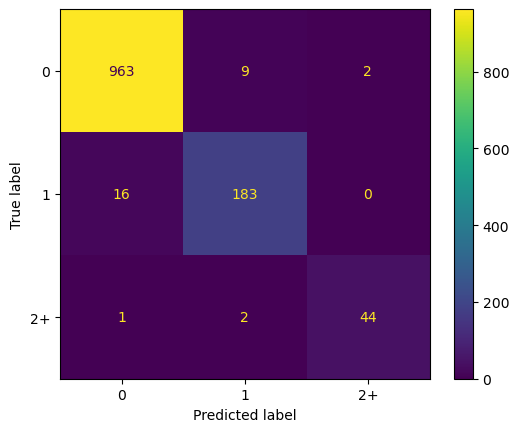

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.3, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(class_weight = None, criterion = 'entropy', max_depth = None, max_features = None, min_samples_split = 7,
                                random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp_3 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

In [40]:
feature_names = X.columns
feature_importance = pd.DataFrame(forest.feature_importances_, index = feature_names).sort_values(0, ascending=False)
feature_importance

,0
iron,0.139960
longitude,0.079206
ammonium,0.062679
nitrate std,0.049562
SST,0.038018
...,...
silva_shannon,0.000071
silva_func_diversity,0.000065
silva_species_rich,0.000045
silva_ace,0.000025


<Axes: >

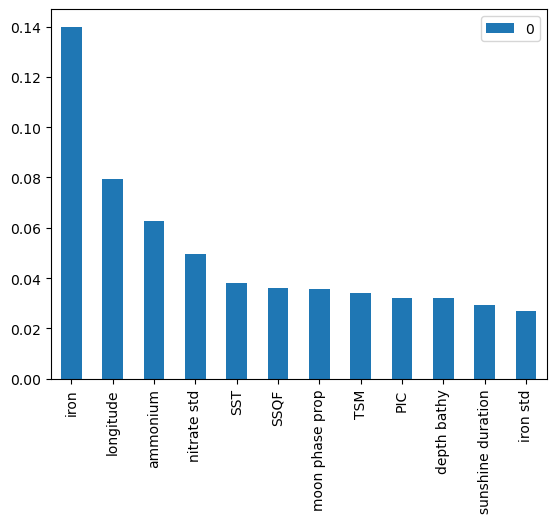

In [43]:
feature_importance.head(12).plot(kind='bar')

<Axes: >

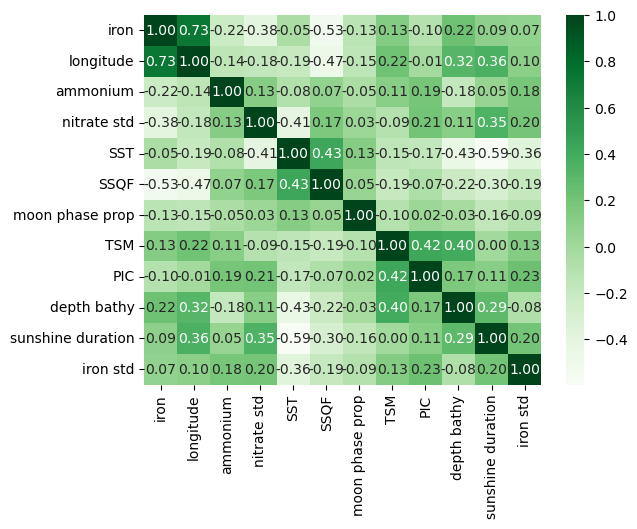

In [46]:
# 1. Get top N features
top_n = 12
top_features = feature_importance.head(top_n).index.tolist()

# 2. Filter dataset for top features
X_top = X[top_features]

# 3. Compute correlation matrix
correlation_matrix = X_top.corr()

#X = feature_importance.iloc[0:20]
#matrix = X.corr()

# plotting correlation matrix
sns.heatmap(correlation_matrix, cmap="Greens", annot=True, fmt=".2f")

In [22]:
y_bin = label_binarize(y, classes=['0', '1', '2+'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, stratify = y_bin, test_size=0.2, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = OneVsRestClassifier(RandomForestClassifier(class_weight = None, criterion = 'entropy', 
                                                    max_depth = None, max_features = None, min_samples_split = 7, random_state=0))
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print(classification_report(y_test, y_pred))

cross validation scores: [0.97420147 0.98154982 0.97785978 0.96309963 0.96801968]
0.9729 accuracy with a standard deviation of 0.0066
Accuracy: 96.44%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       650
           1       0.92      0.89      0.90       133
           2       0.91      0.97      0.94        31

   micro avg       0.97      0.96      0.97       814
   macro avg       0.93      0.95      0.94       814
weighted avg       0.97      0.96      0.97       814
 samples avg       0.96      0.96      0.96       814



C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


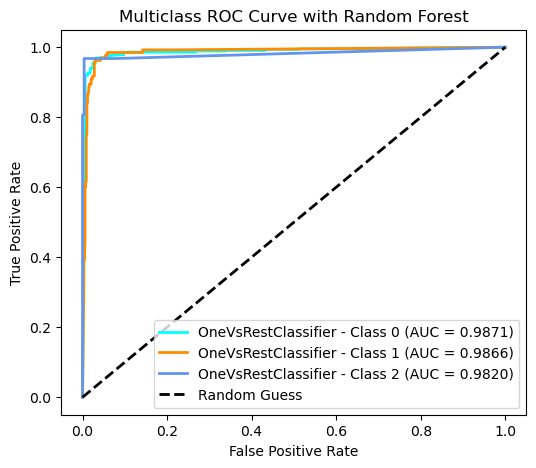

In [23]:
fpr = dict()
tpr = dict()
roc_auc = dict()

model = [forest]

plt.figure(figsize=(6, 5))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

for clf in model:
    for i, color in zip(range(clf.classes_.shape[0]), colors):
        fpr[i], tpr[i], _ = roc_curve(
            y_test[:, i], clf.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{clf.__class__.__name__} - Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Random Forest')
plt.legend(loc="lower right")
plt.show()